In [6]:
import ee

ee.Authenticate()
ee.Initialize(project='arctic-dynamo-306614')

In [7]:
!pip install geemap -q
import ee, geemap
ee.Initialize(project='arctic-dynamo-306614')


In [8]:
!pip install pycrs -q


  Preparing metadata (setup.py) ... done


In [9]:
import os
files = os.listdir('/content/')
for f in files:
    print(f)

.config
drive
sample_data


CRS: EPSG:32643
Shape: (48, 2)
Columns: ['Name', 'geometry']


<Axes: >

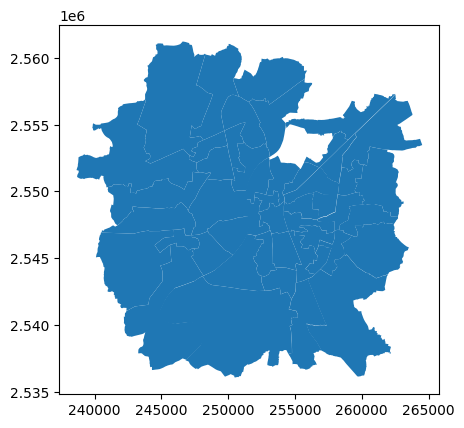

In [12]:
import geopandas as gpd

gdf = gpd.read_file('/content/REPROJECTEDSHAPEFILEWARDAHMEDABAD.shp')
print("CRS:", gdf.crs)
print("Shape:", gdf.shape)
print("Columns:", gdf.columns.tolist())
gdf.plot()

Reprojected CRS: EPSG:4326
Dissolved shape: (1, 2)
Bounds: [72.449281  22.9139487 72.7014909 23.140458 ]


<Axes: >

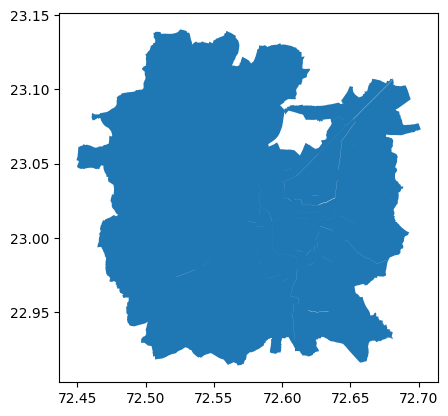

In [13]:
# Reproject to WGS84 for GEE compatibility
gdf_wgs84 = gdf.to_crs("EPSG:4326")
print("Reprojected CRS:", gdf_wgs84.crs)

# Dissolve all wards into one single Ahmedabad boundary
ahmedabad = gdf_wgs84.dissolve()
print("Dissolved shape:", ahmedabad.shape)

# Quick check of coordinates — should show ~72-73 longitude, ~22-23 latitude
print("Bounds:", ahmedabad.total_bounds)

ahmedabad.plot()

In [14]:
# Use bounding box of Ahmedabad instead
bounds = ahmedabad.total_bounds  # [minx, miny, maxx, maxy]
print("Bounds:", bounds)

roi = ee.Geometry.Rectangle([
    float(bounds[0]),  # min longitude
    float(bounds[1]),  # min latitude
    float(bounds[2]),  # max longitude
    float(bounds[3])   # max latitude
])
print("ROI created successfully")
print("ROI bounds:", roi.bounds().getInfo())

Bounds: [72.449281  22.9139487 72.7014909 23.140458 ]
ROI created successfully
ROI bounds: {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[72.449281, 22.913948699999967], [72.7014909, 22.913948699999967], [72.7014909, 23.14050814904196], [72.449281, 23.14050814904196], [72.449281, 22.913948699999967]]]}


In [15]:
# Landsat 8 collection — summer 2024
l8 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") \
       .filterBounds(roi) \
       .filterDate('2024-04-01', '2024-06-30') \
       .filter(ee.Filter.lt('CLOUD_COVER', 10))

print("Scenes found:", l8.size().getInfo())

# Compute LST in Celsius
def compute_lst(image):
    thermal = image.select('ST_B10').multiply(0.00341802).add(149.0)
    lst_celsius = thermal.subtract(273.15)
    return lst_celsius.rename('LST') \
                      .copyProperties(image, ['system:time_start'])

lst_mean = l8.map(compute_lst).mean().clip(roi)
print("LST computed successfully")

Scenes found: 5
LST computed successfully


In [16]:
Map = geemap.Map()
Map.centerObject(roi, 11)
Map.addLayer(
    lst_mean,
    {'min': 25, 'max': 55, 'palette': ['blue', 'cyan', 'yellow', 'orange', 'red']},
    'LST Ahmedabad'
)
Map.addLayer(roi, {}, 'Ahmedabad Boundary')
Map

Map(center=[23.02722159157271, 72.57538594999927], controls=(WidgetControl(options=['position', 'transparent_b…

In [17]:
# Add colorbar and check actual LST values
print("LST Statistics:")
stats = lst_mean.reduceRegion(
    reducer=ee.Reducer.mean()
        .combine(ee.Reducer.min(), sharedInputs=True)
        .combine(ee.Reducer.max(), sharedInputs=True),
    geometry=roi,
    scale=100,
    maxPixels=1e9
)
print(stats.getInfo())

LST Statistics:
{'LST_max': 55.201712648, 'LST_mean': 46.76304732625093, 'LST_min': 31.750677428000017}


In [18]:
Map.save('AMD_LST_map.html')
print("Map saved as AMD_LST_map.html")

Map saved as AMD_LST_map.html


In [19]:
task = ee.batch.Export.image.toDrive(
    image=lst_mean,
    description='AMD_LST_Mean_Summer2024',
    folder='urban_heat_ps1',
    fileNamePrefix='AMD_LST_Mean_Summer2024',
    scale=100,
    region=roi,
    crs='EPSG:4326',
    maxPixels=1e9
)
task.start()
print("Export started — check GEE Tasks tab")
print("Go to: https://code.earthengine.google.com/tasks")

Export started — check GEE Tasks tab
Go to: https://code.earthengine.google.com/tasks


In [20]:
# Simpler thumbnail export
task = ee.batch.Export.image.toDrive(
    image=lst_mean.visualize(
        min=25, max=55,
        palette=['blue','cyan','yellow','orange','red']
    ),
    description='AMD_LST_Thumbnail',
    folder='urban_heat_ps1',
    fileNamePrefix='AMD_LST_Thumbnail',
    scale=100,
    region=roi,
    maxPixels=1e9
)
task.start()
print("Thumbnail export started — check GEE Tasks")

Thumbnail export started — check GEE Tasks


In [21]:
# Sentinel-2 collection — same time period
s2 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
       .filterBounds(roi) \
       .filterDate('2024-04-01', '2024-06-30') \
       .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10)) \
       .median() \
       .clip(roi)

# Compute all four indices
ndvi  = s2.normalizedDifference(['B8','B4']).rename('NDVI')
ndbi  = s2.normalizedDifference(['B11','B8']).rename('NDBI')
ndwi  = s2.normalizedDifference(['B3','B8']).rename('NDWI')
mndwi = s2.normalizedDifference(['B3','B11']).rename('MNDWI')

print("Indices computed successfully")

# Visualise NDVI
Map2 = geemap.Map()
Map2.centerObject(roi, 11)
Map2.addLayer(ndvi,
    {'min':-0.2, 'max':0.8, 'palette':['red','white','green']},
    'NDVI')
Map2.addLayer(ndbi,
    {'min':-0.5, 'max':0.5, 'palette':['blue','white','red']},
    'NDBI')
Map2.addLayer(roi, {}, 'Boundary')
Map2

Indices computed successfully


Map(center=[23.02722159157271, 72.57538594999927], controls=(WidgetControl(options=['position', 'transparent_b…

In [22]:
# Check what bands are actually available
print("Available bands:", s2.bandNames().getInfo())

# Check pixel count for NDWI
ndwi_stats = ndwi.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=roi,
    scale=100,
    maxPixels=1e9
)
print("NDWI mean:", ndwi_stats.getInfo())

mndwi_stats = mndwi.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=roi,
    scale=100,
    maxPixels=1e9
)
print("MNDWI mean:", mndwi_stats.getInfo())

Available bands: ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE']
NDWI mean: {'NDWI': -0.29722456732253727}
MNDWI mean: {'MNDWI': -0.33759084416167456}


In [23]:
Map3 = geemap.Map()
Map3.centerObject(roi, 11)

# NDWI — adjusted range for dry urban area
Map3.addLayer(ndwi,
    {'min': -0.5, 'max': 0.1,
     'palette': ['FF6347','FFA500','FFFF00','00FFFF','0000FF','000080']},
    'NDWI', True)

# MNDWI — adjusted range
Map3.addLayer(mndwi,
    {'min': -0.5, 'max': 0.1,
     'palette': ['FF6347','FFA500','FFFF00','00FFFF','0000FF','000080']},
    'MNDWI', True)

Map3.addLayer(roi, {}, 'Boundary')
Map3

Map(center=[23.02722159157271, 72.57538594999927], controls=(WidgetControl(options=['position', 'transparent_b…

In [24]:
Map4 = geemap.Map()
Map4.centerObject(roi, 11)

# NDVI — red to green (standard vegetation colours)
Map4.addLayer(ndvi,
    {'min': -0.2, 'max': 0.8,
     'palette': ['FF0000','FF4500','FF8C00',
                 'FFFF00','ADFF2F','008000','004d00']},
    'NDVI — vegetation', True)

# NDBI — green to purple (built-up index)
Map4.addLayer(ndbi,
    {'min': -0.5, 'max': 0.5,
     'palette': ['004d00','008000','FFFF00',
                 'FF8C00','CC0000','800080','4B0082']},
    'NDBI — built-up', False)

# NDWI — brown to blue (water content)
Map4.addLayer(ndwi,
    {'min': -0.5, 'max': 0.1,
     'palette': ['8B4513','D2691E','F5DEB3',
                 'ADD8E6','1E90FF','00008B']},
    'NDWI — water', False)

# MNDWI — tan to deep blue (modified water)
Map4.addLayer(mndwi,
    {'min': -0.5, 'max': 0.1,
     'palette': ['A0522D','DAA520','F0E68C',
                 '87CEEB','4169E1','00008B']},
    'MNDWI — modified water', False)

# LST on top for comparison
Map4.addLayer(lst_mean,
    {'min': 25, 'max': 55,
     'palette': ['blue','cyan','yellow','orange','red']},
    'LST — temperature', False)

Map4.addLayer(roi, {}, 'Boundary')
Map4

Map(center=[23.02722159157271, 72.57538594999927], controls=(WidgetControl(options=['position', 'transparent_b…

In [25]:
Map5 = geemap.Map()
Map5.centerObject(roi, 11)

# LST — classic blue to red heat
Map5.addLayer(lst_mean,
    {'min': 25, 'max': 55,
     'palette': ['000080','0000FF','00FFFF',
                 'FFFF00','FF8C00','FF0000','8B0000']},
    'LST — surface temperature', True)

# NDVI — white to dark green only (no red)
Map5.addLayer(ndvi,
    {'min': 0.0, 'max': 0.6,
     'palette': ['ffffff','f7fcb9','addd8e',
                 '41ab5d','006837','00441b']},
    'NDVI — vegetation density', False)

# NDBI — white to dark purple only
Map5.addLayer(ndbi,
    {'min': -0.1, 'max': 0.4,
     'palette': ['ffffff','dadaeb','bcbddc',
                 '9e9ac8','756bb1','54278f','3f007d']},
    'NDBI — built-up intensity', False)

# NDWI — white to dark blue only
Map5.addLayer(ndwi,
    {'min': -0.4, 'max': 0.0,
     'palette': ['ffffff','deebf7','9ecae1',
                 '4292c6','2171b5','084594']},
    'NDWI — water content', False)

Map5.addLayer(roi, {}, 'Boundary')
Map5

Map(center=[23.02722159157271, 72.57538594999927], controls=(WidgetControl(options=['position', 'transparent_b…

In [26]:
Map5.addLayer(mndwi,
    {'min': -0.4, 'max': 0.0,
     'palette': ['ffffff','e5f5f9','99d8c9',
                 '41ae76','006d2c','00441b']},
    'MNDWI — modified water index', False)

Map5

Map(bottom=227967.0, center=[23.02722159157271, 72.57538594999927], controls=(WidgetControl(options=['position…

In [27]:
# Stack all layers together
full_stack = lst_mean.addBands([ndvi, ndbi, ndwi, mndwi])

print("Band names:", full_stack.bandNames().getInfo())

# Export to Google Drive
task = ee.batch.Export.image.toDrive(
    image=full_stack,
    description='AMD_LST_Indices_2024',
    folder='urban_heat_ps1',
    fileNamePrefix='AMD_LST_Indices_2024',
    scale=100,
    region=roi,
    crs='EPSG:4326',
    maxPixels=1e9
)
task.start()
print("Export started successfully")
print("Check progress at: https://code.earthengine.google.com/tasks")

Band names: ['LST', 'NDVI', 'NDBI', 'NDWI', 'MNDWI']
Export started successfully
Check progress at: https://code.earthengine.google.com/tasks


In [28]:
# Albedo from Landsat 8 bands
l8_img = l8.median().clip(roi)

def compute_albedo(image):
    b2 = image.select('SR_B2').multiply(0.0000275).add(-0.2)
    b4 = image.select('SR_B4').multiply(0.0000275).add(-0.2)
    b5 = image.select('SR_B5').multiply(0.0000275).add(-0.2)
    b6 = image.select('SR_B6').multiply(0.0000275).add(-0.2)
    b7 = image.select('SR_B7').multiply(0.0000275).add(-0.2)
    return b2.multiply(0.356) \
             .add(b4.multiply(0.130)) \
             .add(b5.multiply(0.373)) \
             .add(b6.multiply(0.085)) \
             .add(b7.multiply(0.072)) \
             .subtract(0.0018) \
             .rename('albedo')

albedo = compute_albedo(l8_img)

# Emissivity from NDVI
fv = ndvi.subtract(0.2).divide(0.3).pow(2).clamp(0, 1)
emissivity = fv.multiply(0.009).add(0.985).rename('emissivity')

# Net radiation Rn
lst_k = lst_mean.add(273.15)
Rs_down = ee.Image(600)
Rn = Rs_down.multiply(ee.Image(1).subtract(albedo)) \
     .subtract(emissivity.multiply(5.67e-8) \
     .multiply(lst_k.pow(4)).multiply(0.1)) \
     .rename('Rn')

# Soil heat flux G
G = lst_mean.divide(albedo.max(0.01)) \
    .multiply(ee.Image(0.0038).add(albedo.multiply(0.0074))) \
    .multiply(ee.Image(1).subtract(ndvi.pow(4).multiply(0.98))) \
    .multiply(Rn).rename('G')

# Latent and sensible heat
EF = ndvi.clamp(0, 0.9).divide(0.9).rename('EF')
LE = Rn.subtract(G).multiply(EF).rename('LE')
H  = Rn.subtract(G).subtract(LE).rename('H')

# Bowen ratio — key physics feature
bowen = H.divide(LE.abs().max(10)).rename('bowen_ratio')

print("Physics features computed successfully")

# Check values
stats = bowen.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=roi,
    scale=100,
    maxPixels=1e9
)
print("Mean Bowen ratio:", stats.getInfo())

Physics features computed successfully
Mean Bowen ratio: {'bowen_ratio': -3.4976050396298786}


In [29]:
# Fix — clip LE to avoid negative values
LE = Rn.subtract(G).multiply(EF).max(0).rename('LE')
H  = Rn.subtract(G).subtract(LE).rename('H')

# Bowen ratio with proper clipping
bowen = H.divide(LE.add(10)).rename('bowen_ratio')

print("Physics features recomputed")

# Check again
stats = bowen.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=roi,
    scale=100,
    maxPixels=1e9
)
print("Mean Bowen ratio:", stats.getInfo())

# Also check all physics stats
physics_stats = Rn.addBands([G, H, LE]) \
    .reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=100,
        maxPixels=1e9
    )
print("Physics stats:", physics_stats.getInfo())

Physics features recomputed
Mean Bowen ratio: {'bowen_ratio': -10.71421281403087}
Physics stats: {'G': 527.3989178040706, 'H': -107.01196431178106, 'LE': 0.28836530045170616, 'Rn': 420.6753187927464}


In [30]:
# Fix 1 — G must be a fraction of Rn, not exceed it
# Standard SEBAL: G = 0.1 * Rn for urban, 0.3 * Rn for vegetation
G = Rn.multiply(0.1).rename('G')

# Fix 2 — EF based on NDVI properly scaled
EF = ndvi.clamp(0.0, 0.9).divide(0.9).clamp(0.05, 0.95)

# Fix 3 — available energy
avail = Rn.subtract(G)

# LE and H from available energy
LE = avail.multiply(EF).max(0).rename('LE')
H  = avail.subtract(LE).rename('H')

# Bowen ratio
bowen = H.divide(LE.add(1)).rename('bowen_ratio')

# Recheck all stats
stats = Rn.addBands([G, H, LE, bowen]) \
    .reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=100,
        maxPixels=1e9
    )
print("Fixed physics stats:")
for k, v in stats.getInfo().items():
    print(f"  {k}: {round(v, 3)}")

Fixed physics stats:
  G: 42.068
  H: 284.26
  LE: 94.348
  Rn: 420.675
  bowen_ratio: 4.597


In [31]:
# Stack all physics features
physics_stack = Rn.addBands([G, H, LE, bowen, albedo, emissivity])
print("Physics bands:", physics_stack.bandNames().getInfo())

# Export to Drive
task2 = ee.batch.Export.image.toDrive(
    image=physics_stack,
    description='AMD_Physics_Features_2024',
    folder='urban_heat_ps1',
    fileNamePrefix='AMD_Physics_Features_2024',
    scale=100,
    region=roi,
    crs='EPSG:4326',
    maxPixels=1e9
)
task2.start()
print("Physics export started")
print("Check: https://code.earthengine.google.com/tasks")

Physics bands: ['Rn', 'G', 'H', 'LE', 'bowen_ratio', 'albedo', 'emissivity']
Physics export started
Check: https://code.earthengine.google.com/tasks


In [32]:
Map7 = geemap.Map()
Map7.centerObject(roi, 11)

# Bowen ratio — low (blue/green) = cool vegetated, high (red) = hot urban
Map7.addLayer(bowen,
    {'min': 0, 'max': 8,
     'palette': ['000080','0000FF','00FFFF',
                 'FFFF00','FF8C00','FF0000','8B0000']},
    'Bowen Ratio — heat driver', True)

# H sensible heat map
Map7.addLayer(H,
    {'min': 0, 'max': 500,
     'palette': ['white','yellow','orange','red','darkred']},
    'Sensible Heat H', False)

Map7.addLayer(roi, {}, 'Boundary')
Map7

Map(center=[23.02722159157271, 72.57538594999927], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
!pip install geemap -q
import ee, geemap
ee.Authenticate()

In [ ]:
ee.Initialize(project='arctic-dynamo-306614')
print("GEE connected successfully")

In [ ]:
!pip install geemap -q
import ee, geemap
ee.Authenticate()   # add this line
ee.Initialize(project='arctic-dynamo-306614')
print("GEE connected")

In [33]:
!pip install geemap -q
import ee, geemap
ee.Initialize(project='arctic-dynamo-306614')

# Ahmedabad ROI from bounds
roi = ee.Geometry.Rectangle([72.4498, 22.9139, 72.7015, 23.1405])

# Landsat 8 LST
l8 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") \
       .filterBounds(roi) \
       .filterDate('2024-04-01', '2024-06-30') \
       .filter(ee.Filter.lt('CLOUD_COVER', 10))

def compute_lst(image):
    thermal = image.select('ST_B10').multiply(0.00341802).add(149.0)
    return thermal.subtract(273.15).rename('LST') \
                  .copyProperties(image, ['system:time_start'])

lst_mean = l8.map(compute_lst).mean().clip(roi)

# Sentinel-2 indices
s2 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
       .filterBounds(roi) \
       .filterDate('2024-04-01', '2024-06-30') \
       .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10)) \
       .median().clip(roi)

ndvi  = s2.normalizedDifference(['B8','B4']).rename('NDVI')
ndbi  = s2.normalizedDifference(['B11','B8']).rename('NDBI')
ndwi  = s2.normalizedDifference(['B3','B8']).rename('NDWI')
mndwi = s2.normalizedDifference(['B3','B11']).rename('MNDWI')

# Physics features
def compute_albedo(image):
    b2 = image.select('SR_B2').multiply(0.0000275).add(-0.2)
    b4 = image.select('SR_B4').multiply(0.0000275).add(-0.2)
    b5 = image.select('SR_B5').multiply(0.0000275).add(-0.2)
    b6 = image.select('SR_B6').multiply(0.0000275).add(-0.2)
    b7 = image.select('SR_B7').multiply(0.0000275).add(-0.2)
    return b2.multiply(0.356).add(b4.multiply(0.130)) \
             .add(b5.multiply(0.373)).add(b6.multiply(0.085)) \
             .add(b7.multiply(0.072)).subtract(0.0018) \
             .rename('albedo')

l8_img     = l8.median().clip(roi)
albedo     = compute_albedo(l8_img)
fv         = ndvi.subtract(0.2).divide(0.3).pow(2).clamp(0,1)
emissivity = fv.multiply(0.009).add(0.985).rename('emissivity')
lst_k      = lst_mean.add(273.15)
Rs_down    = ee.Image(600)
Rn = Rs_down.multiply(ee.Image(1).subtract(albedo)) \
     .subtract(emissivity.multiply(5.67e-8) \
     .multiply(lst_k.pow(4)).multiply(0.1)).rename('Rn')
G  = Rn.multiply(0.1).rename('G')
EF = ndvi.clamp(0.0, 0.9).divide(0.9).clamp(0.05, 0.95)
LE = Rn.subtract(G).multiply(EF).max(0).rename('LE')
H  = Rn.subtract(G).subtract(LE).rename('H')
bowen = H.divide(LE.add(1)).rename('bowen_ratio')

# Export full stack
full_stack = lst_mean.addBands([ndvi, ndbi, ndwi, mndwi,
                                 Rn, G, H, LE, bowen,
                                 albedo, emissivity])

print("Bands:", full_stack.bandNames().getInfo())

task = ee.batch.Export.image.toDrive(
    image=full_stack,
    description='AMD_Full_Stack_2024',
    folder='urban_heat_ps1',
    fileNamePrefix='AMD_Full_Stack_2024',
    scale=100,
    region=roi,
    crs='EPSG:4326',
    maxPixels=1e9
)
task.start()
print("Export started — check https://code.earthengine.google.com/tasks")

Bands: ['LST', 'NDVI', 'NDBI', 'NDWI', 'MNDWI', 'Rn', 'G', 'H', 'LE', 'bowen_ratio', 'albedo', 'emissivity']
Export started — check https://code.earthengine.google.com/tasks


In [34]:
# Cast everything to Float32 to fix type mismatch
full_stack_f32 = full_stack.toFloat()

print("Bands:", full_stack_f32.bandNames().getInfo())

task = ee.batch.Export.image.toDrive(
    image=full_stack_f32,
    description='AMD_Full_Stack_2024',
    folder='urban_heat_ps1',
    fileNamePrefix='AMD_Full_Stack_2024',
    scale=100,
    region=roi,
    crs='EPSG:4326',
    maxPixels=1e9
)
task.start()
print("Export started!")
print("Check: https://code.earthengine.google.com/tasks")

Bands: ['LST', 'NDVI', 'NDBI', 'NDWI', 'MNDWI', 'Rn', 'G', 'H', 'LE', 'bowen_ratio', 'albedo', 'emissivity']
Export started!
Check: https://code.earthengine.google.com/tasks


  Saved AMD_LST.png
  Saved AMD_NDVI.png
  Saved AMD_NDBI.png
  Saved AMD_NDWI.png
  Saved AMD_MNDWI.png
  Saved AMD_Bowen.png


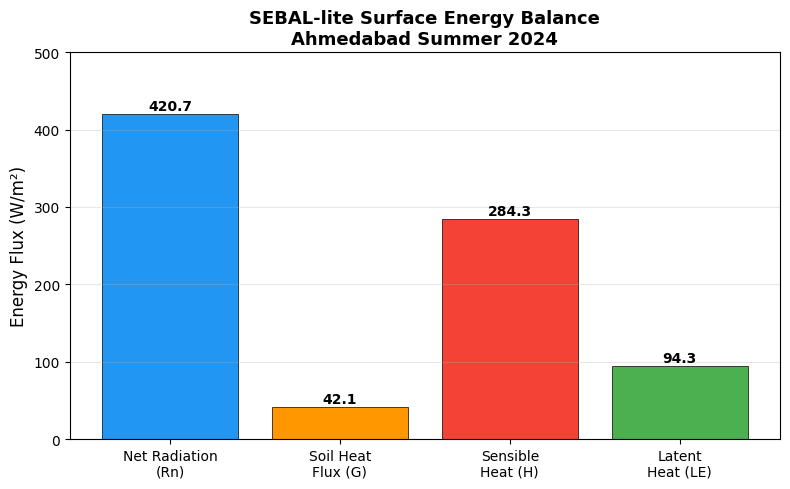

Energy balance chart saved

✓ ALL MODULE 1 OUTPUTS SAVED
  AMD_Bowen.png                                   949.5 KB
  AMD_LST.png                                     862.8 KB
  AMD_LST_interactive_map.html                    146.8 KB
  AMD_MNDWI.png                                   633.7 KB
  AMD_NDBI.png                                    853.8 KB
  AMD_NDVI.png                                    969.9 KB
  AMD_NDWI.png                                    755.5 KB
  AMD_energy_balance.png                           49.1 KB
  key_results.txt                                   1.8 KB


In [36]:
# Save all thumbnails using correct geemap API
layers = {
    'LST':   (lst_mean, {'min':25,   'max':55,
              'palette':['000080','0000FF','00FFFF','FFFF00','FF8C00','FF0000','8B0000']}),
    'NDVI':  (ndvi,     {'min':0.0,  'max':0.6,
              'palette':['ffffff','f7fcb9','addd8e','41ab5d','006837','00441b']}),
    'NDBI':  (ndbi,     {'min':-0.1, 'max':0.4,
              'palette':['ffffff','dadaeb','bcbddc','9e9ac8','756bb1','54278f','3f007d']}),
    'NDWI':  (ndwi,     {'min':-0.4, 'max':0.0,
              'palette':['ffffff','deebf7','9ecae1','4292c6','2171b5','084594']}),
    'MNDWI': (mndwi,    {'min':-0.4, 'max':0.0,
              'palette':['ffffff','e5f5f9','99d8c9','41ae76','006d2c','00441b']}),
    'Bowen': (bowen,    {'min':0,    'max':8,
              'palette':['000080','0000FF','00FFFF','FFFF00','FF8C00','FF0000','8B0000']}),
}

for name, (img, vis) in layers.items():
    url = img.visualize(**vis).getThumbURL({
        'region': roi,
        'dimensions': 800,
        'format': 'png'
    })
    import requests
    response = requests.get(url)
    filepath = docs_path + f'AMD_{name}.png'
    with open(filepath, 'wb') as f:
        f.write(response.content)
    print(f"  Saved AMD_{name}.png")

# Energy balance chart
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,5))
physics = {'Net Radiation\n(Rn)':420.68,
           'Soil Heat\nFlux (G)':42.07,
           'Sensible\nHeat (H)':284.26,
           'Latent\nHeat (LE)':94.35}
colors = ['#2196F3','#FF9800','#F44336','#4CAF50']
bars = ax.bar(physics.keys(), physics.values(),
              color=colors, edgecolor='black', linewidth=0.5)
for bar,val in zip(bars, physics.values()):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+5,
            f'{val:.1f}', ha='center',
            fontsize=10, fontweight='bold')
ax.set_ylabel('Energy Flux (W/m²)', fontsize=12)
ax.set_title('SEBAL-lite Surface Energy Balance\nAhmedabad Summer 2024',
             fontsize=13, fontweight='bold')
ax.set_ylim(0,500)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(docs_path+'AMD_energy_balance.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Energy balance chart saved")

# Final file list
print("\n✓ ALL MODULE 1 OUTPUTS SAVED")
for f in sorted(os.listdir(docs_path)):
    size = os.path.getsize(docs_path+f)/1024
    print(f"  {f:45s} {size:7.1f} KB")

In [39]:
# NDMI = (NIR - SWIR1) / (NIR + SWIR1)
# Landsat 8: NIR = B5, SWIR1 = B6
# Sentinel-2: NIR = B8, SWIR1 = B11

# From your existing s2 image
ndmi = s2.normalizedDifference(['B8','B11']).rename('NDMI')

# Check stats
ndmi_stats = ndmi.reduceRegion(
    reducer=ee.Reducer.mean()
            .combine(ee.Reducer.min(), sharedInputs=True)
            .combine(ee.Reducer.max(), sharedInputs=True),
    geometry=roi,
    scale=100,
    maxPixels=1e9
)
print("NDMI stats:", ndmi_stats.getInfo())

# Visualize
Map_ndmi = geemap.Map()
Map_ndmi.centerObject(roi, 11)
Map_ndmi.addLayer(ndmi,
    {'min': -0.5, 'max': 0.2,
     'palette': ['8B0000','FF4500','FF8C00',
                 'FFFF00','90EE90','008000','004d00']},
    'NDMI — moisture index')
Map_ndmi.addLayer(roi, {}, 'Boundary')
Map_ndmi

# Save thumbnail
url = ndmi.visualize(
    min=-0.5, max=0.2,
    palette=['8B0000','FF4500','FF8C00',
             'FFFF00','90EE90','008000','004d00']
).getThumbURL({'region': roi, 'dimensions': 800, 'format': 'png'})

import requests, os
docs_path = '/content/drive/MyDrive/urban_heat_ps1/docs/'
r = requests.get(url)
with open(docs_path + 'AMD_NDMI.png', 'wb') as f:
    f.write(r.content)
print("NDMI thumbnail saved")

# Re-export full stack with NDMI added
full_stack_v2 = lst_mean.addBands([
    ndvi, ndbi, ndwi, mndwi, ndmi,  # added NDMI
    Rn, G, H, LE, bowen, albedo, emissivity
]).toFloat()

print("Updated bands:", full_stack_v2.bandNames().getInfo())

task = ee.batch.Export.image.toDrive(
    image=full_stack_v2,
    description='AMD_Full_Stack_v2_2024',
    folder='urban_heat_ps1',
    fileNamePrefix='AMD_Full_Stack_v2_2024',
    scale=100,
    region=roi,
    crs='EPSG:4326',
    maxPixels=1e9
)
task.start()
print("Full stack v2 export started")
print("Check: https://code.earthengine.google.com/tasks")

NDMI stats: {'NDMI_max': 0.5131038838017051, 'NDMI_mean': -0.043878858098134035, 'NDMI_min': -0.4061032863849765}
NDMI thumbnail saved
Updated bands: ['LST', 'NDVI', 'NDBI', 'NDWI', 'MNDWI', 'NDMI', 'Rn', 'G', 'H', 'LE', 'bowen_ratio', 'albedo', 'emissivity']
Full stack v2 export started
Check: https://code.earthengine.google.com/tasks
